# Parte 2: Análisis Exploratorio de Datos (EDA)

Este notebook contiene el análisis estadístico y visual del conjunto de datos ya limpio.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos limpios
df = pd.read_csv('../data/processed/rita_limpio.csv')
sns.set_theme(style="whitegrid")

print("Resumen General:")
df.info()

Resumen General:
<class 'pandas.DataFrame'>
RangeIndex: 82106 entries, 0 to 82105
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   IDPTE                 82106 non-null  int64  
 1   PTESXN                82106 non-null  str    
 2   FECHA_DIAGNÓSTICO     82106 non-null  str    
 3   EDAD_DIAGNÓSTICO      82106 non-null  int64  
 4   TOPOGRAFÍA            82089 non-null  str    
 5   TOPOGRAFÍA_N          82106 non-null  str    
 6   MORFOLOGÍA            81866 non-null  float64
 7   MORFOLOGÍA_N          82106 non-null  str    
 8   COMPORTAMIENTO        82106 non-null  int64  
 9   COMPORTAMIENTO_N      82106 non-null  str    
 10  METODO_DIAGNÓSTICO    82106 non-null  int64  
 11  METODO_DIAGNÓSTICO_N  82106 non-null  str    
 12  SEXO_NUM              82106 non-null  int64  
dtypes: float64(1), int64(5), str(7)
memory usage: 8.1 MB


## 2.1 Resúmenes Estadísticos

In [3]:
print("Estadísticas Descriptivas:")
display(df.describe())

Estadísticas Descriptivas:


,IDPTE,EDAD_DIAGNÓSTICO,MORFOLOGÍA,COMPORTAMIENTO,METODO_DIAGNÓSTICO,SEXO_NUM
count,82106.000000,82106.000000,81866.000000,82106.000000,82106.000000,82106.000000
mean,65537.097033,55.080981,8365.622322,6.699096,17.857635,0.597971
std,32033.339328,15.448872,478.663659,61.188286,99.093567,0.490311
min,316.000000,15.000000,8000.000000,0.000000,1.000000,0.000000
25%,39389.250000,44.000000,8070.000000,3.000000,8.000000,0.000000
50%,68098.500000,57.000000,8140.000000,3.000000,8.000000,1.000000
75%,93190.750000,66.000000,8500.000000,3.000000,8.000000,1.000000
max,121661.000000,102.000000,9989.000000,999.000000,999.000000,1.000000


## 2.2 Agrupamiento de Información
Agrupamos por Sexo para ver la edad promedio de diagnóstico.

In [4]:
resumen_sexo = df.groupby('PTESXN')['EDAD_DIAGNÓSTICO'].agg(['mean', 'median', 'std', 'count'])
print("Análisis de Edad por Sexo:")
display(resumen_sexo)

Análisis de Edad por Sexo:


,mean,median,std,count
PTESXN,,,,
Hombre,57.916932,60.0,15.140900,33009
Mujer,53.174308,54.0,15.361101,49097


## 2.3 Análisis Gráfico Univariado
### Histograma de Edades

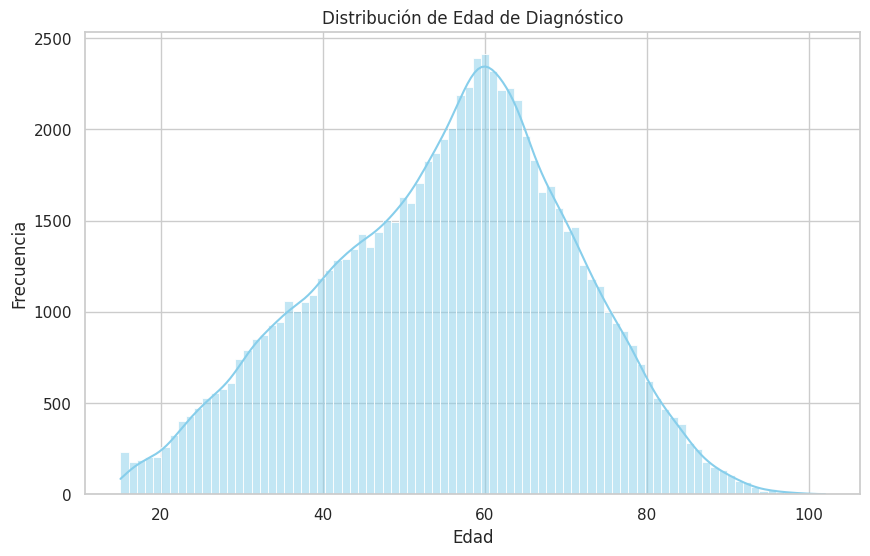

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['EDAD_DIAGNÓSTICO'], kde=True, color='skyblue')
plt.title('Distribución de Edad de Diagnóstico')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

### Gráfico de Torta (Proporción de Sexo)

In [6]:
plt.figure(figsize=(8, 8))
df['PTESXN'].value_index.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribución por Sexo')
plt.ylabel('')
plt.show()

AttributeError: 'Series' object has no attribute 'value_index'

<Figure size 800x800 with 0 Axes>

## 2.4 Análisis Multivariado
### Matriz de Correlación

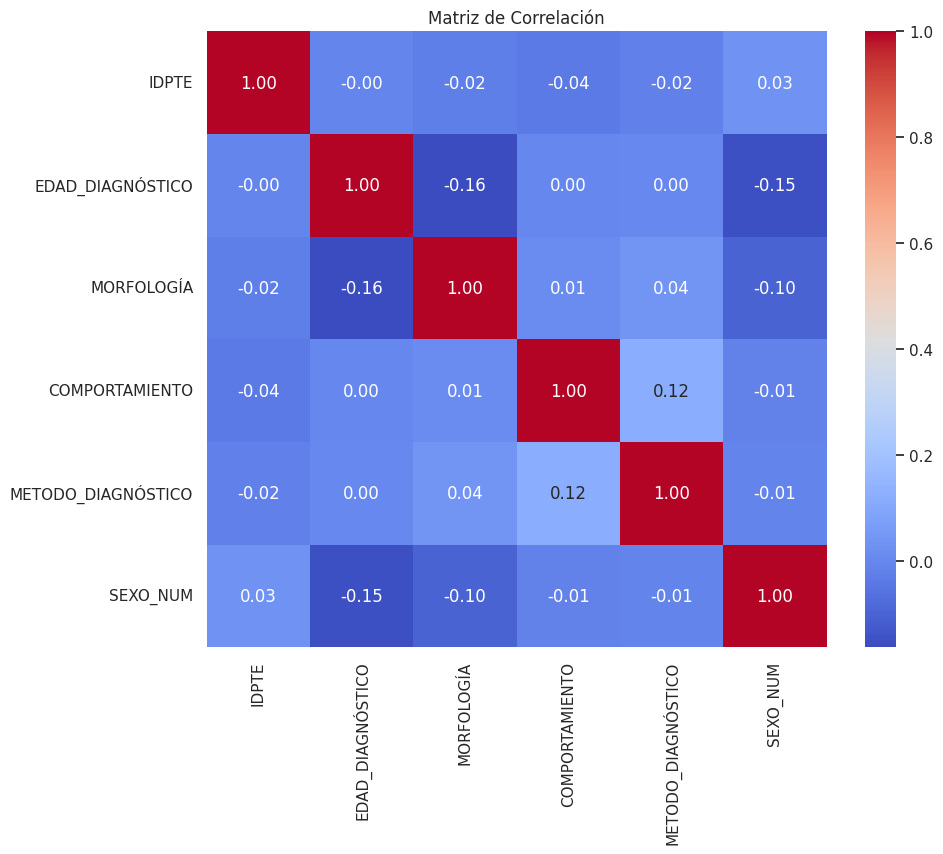

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

### Boxplots por Categoría (Topografía vs Edad)

/tmp/ipykernel_27060/110648048.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_subset, x='TOPOGRAFÍA_N', y='EDAD_DIAGNÓSTICO', palette='Set3')


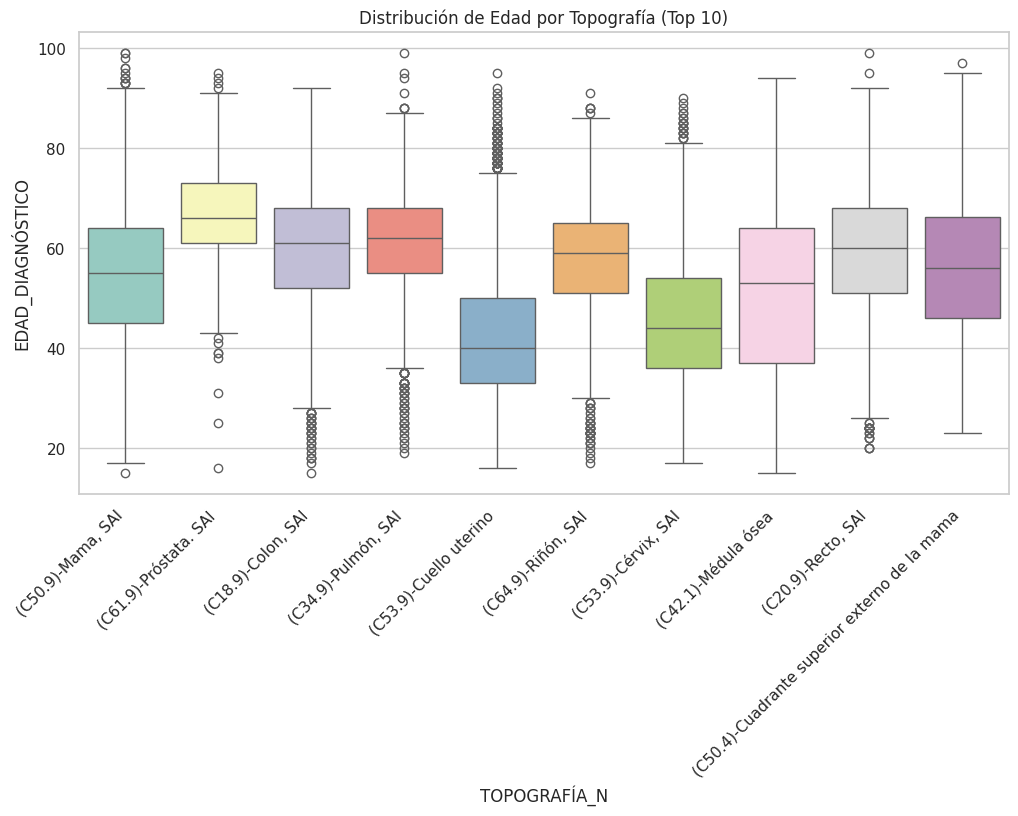

In [ ]:
# Tomamos las 10 topografías más frecuentes para que el gráfico sea legible
top_topografias = df['TOPOGRAFÍA_N'].value_counts().nlargest(10).index
df_subset = df[df['TOPOGRAFÍA_N'].isin(top_topografias)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_subset, x='TOPOGRAFÍA_N', y='EDAD_DIAGNÓSTICO', palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Edad por Topografía (Top 10)')
plt.show()